In [63]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec

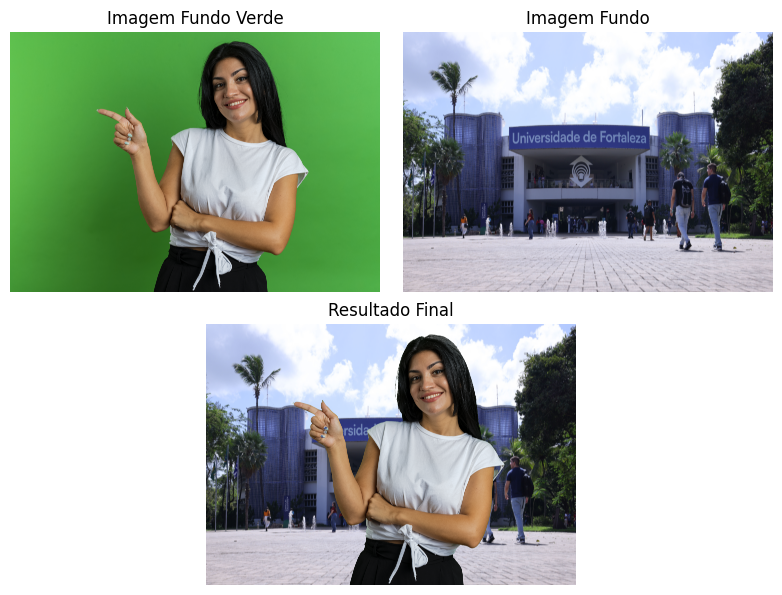

In [65]:

# 1. Carregar imagem com fundo verde e novo fundo
fg = cv2.imread("projeto_1/img_fundo_verde_1.jpg")   # pessoa/objeto com fundo verde
bg = cv2.imread("projeto_1/background_1.png")         # nova imagem de fundo

# Redimensionar fundo para o mesmo tamanho
bg = cv2.resize(bg, (fg.shape[1], fg.shape[0]))

# 2. Converter para HSV (mais fácil isolar o verde)
hsv = cv2.cvtColor(fg, cv2.COLOR_BGR2HSV)

# 3. Definir intervalo de verde (ajuste os valores conforme sua imagem)
lower_green = np.array([35, 40, 40])   # H, S, V
upper_green = np.array([85, 255, 255])

# 4. Criar máscara onde é verde
mask = cv2.inRange(hsv, lower_green, upper_green)

# 5. Inverter máscara (255 = sujeito, 0 = fundo verde)
mask_inv = cv2.bitwise_not(mask)

# 6. Isolar o objeto (remove o verde)
fg_no_green = cv2.bitwise_and(fg, fg, mask=mask_inv)

# 7. Isolar apenas a região onde era verde no background
bg_region = cv2.bitwise_and(bg, bg, mask=mask)

# 8. Combinar
final = cv2.add(fg_no_green, bg_region)
final = cv2.cvtColor(final,cv2.COLOR_BGR2RGB)

fig = plt.figure(figsize=(8, 6))

# Grid 2 linhas x 2 colunas
gs = GridSpec(2, 2, figure=fig)


ax_topl = fig.add_subplot(gs[0,0])
ax_topl.imshow(cv2.cvtColor(fg,cv2.COLOR_BGR2RGB))  
ax_topl.set_axis_off()
ax_topl.set_title("Imagem Fundo Verde")


ax_topr = fig.add_subplot(gs[0,1])
ax_topr.imshow(cv2.cvtColor(bg,cv2.COLOR_BGR2RGB))  
ax_topr.set_axis_off()
ax_topr.set_title("Imagem Fundo")

ax_bottom = fig.add_subplot(gs[1,:])
ax_bottom.imshow(final)
ax_bottom.set_axis_off()
ax_bottom.set_title("Resultado Final")

plt.tight_layout()
plt.show()

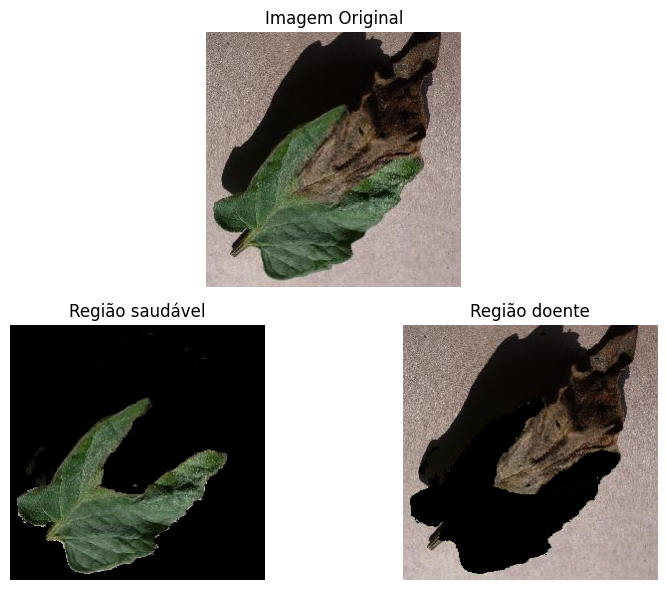

In [67]:
# 1. Carregar imagem
img = cv2.imread("projeto_2/img_folha_3.JPG")

# 2. Converter para HSV (mais robusto p/ cor)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# 3. Definir faixa de cor (ex.: verde)
# Ajuste esses valores conforme sua imagem
lower = (25, 20, 20)
upper = (70, 255, 230)
# 4. Criar máscara binária
mask = cv2.inRange(hsv, lower, upper)
mask_inv = cv2.bitwise_not(mask)
# 5. Aplicar máscara na imagem original (segmento colorido)
bom = cv2.bitwise_and(img, img, mask=mask)
bom = cv2.cvtColor(bom,cv2.COLOR_BGR2RGB)
ruim = cv2.bitwise_and(img,img,mask=mask_inv)
ruim = cv2.cvtColor(ruim,cv2.COLOR_BGR2RGB)

fig = plt.figure(figsize=(8, 6))

# Grid 2 linhas x 2 colunas
gs = GridSpec(2, 2, figure=fig)


ax_top = fig.add_subplot(gs[0,:])
ax_top.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))  
ax_top.set_axis_off()
ax_top.set_title("Imagem Original")


ax_botl = fig.add_subplot(gs[1,0])
ax_botl.imshow(bom)  
ax_botl.set_axis_off()
ax_botl.set_title("Região saudável")

ax_botr = fig.add_subplot(gs[1,1])
ax_botr.imshow(ruim)
ax_botr.set_axis_off()
ax_botr.set_title("Região doente")

plt.tight_layout()
plt.show()

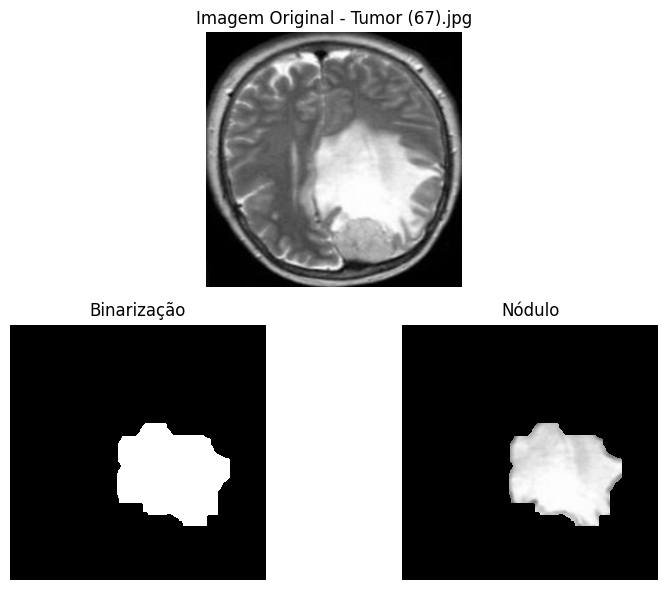

In [69]:
img = cv2.imread("projeto_3/Tumor (67).jpg",cv2.IMREAD_GRAYSCALE)

bin = cv2.threshold(img,200, 255, cv2.THRESH_BINARY)[1]

kernel = np.ones((3,3), np.uint8)

erodido = cv2.erode(bin, kernel, iterations=6)

dilatado = cv2.dilate(erodido, kernel, iterations=9)

mask_inv = cv2.bitwise_not(dilatado)

nodulo = cv2.bitwise_and(img, img, mask=dilatado)


fig = plt.figure(figsize=(8, 6))

# Grid 2 linhas x 2 colunas
gs = GridSpec(2, 2, figure=fig)


ax_top = fig.add_subplot(gs[0,:])
ax_top.imshow(img, cmap="gray")  
ax_top.set_axis_off()
ax_top.set_title("Imagem Original - Tumor (67).jpg")


ax_botl = fig.add_subplot(gs[1,0])
ax_botl.imshow(dilatado, cmap="gray")  
ax_botl.set_axis_off()
ax_botl.set_title("Binarização")

ax_botr = fig.add_subplot(gs[1,1])
ax_botr.imshow(nodulo, cmap="gray")
ax_botr.set_axis_off()
ax_botr.set_title("Nódulo")

plt.tight_layout()
plt.show()

